In [1]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
%matplotlib inline

In [2]:
df_index= pd.read_csv('economic_index.csv')
df_index

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


In [3]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
##drop unnamed

df_index.drop(columns=['Unnamed: 0' , 'year' , 'month'], axis=1 , inplace=True)

In [5]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [6]:
##to ckeck null values

df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

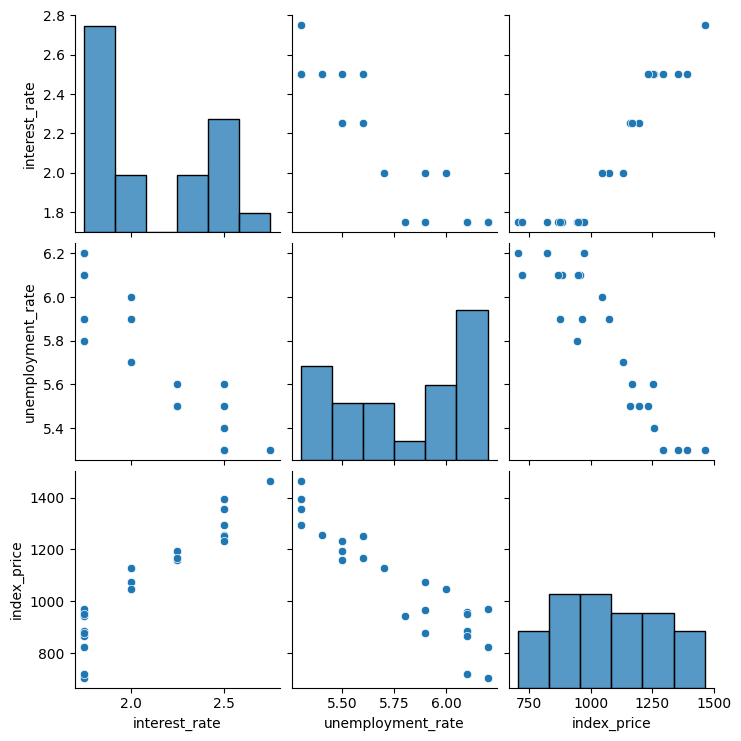

In [7]:
##visualize

import seaborn as sns
sns.pairplot(df_index)

In [8]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


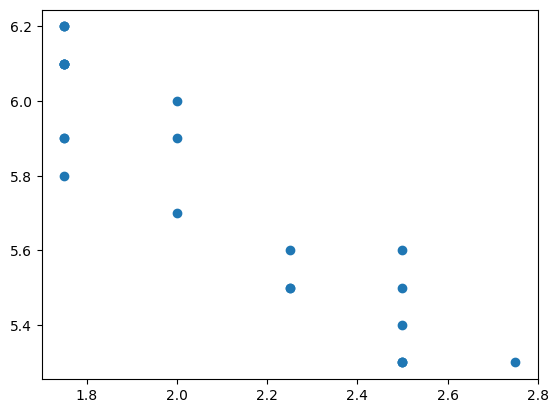

In [9]:
plt.scatter(df_index['interest_rate'] , df_index['unemployment_rate'])

plt.xlabel="intrest_rate"
plt.ylabel="unemployment_rate"

In [10]:
##independent and depndent features
x=df_index[['interest_rate' , 'unemployment_rate']]
y = df_index[['index_price']]

In [11]:
x , y

(    interest_rate  unemployment_rate
 0            2.75                5.3
 1            2.50                5.3
 2            2.50                5.3
 3            2.50                5.3
 4            2.50                5.4
 5            2.50                5.6
 6            2.50                5.5
 7            2.25                5.5
 8            2.25                5.5
 9            2.25                5.6
 10           2.00                5.7
 11           2.00                5.9
 12           2.00                6.0
 13           1.75                5.9
 14           1.75                5.8
 15           1.75                6.1
 16           1.75                6.2
 17           1.75                6.1
 18           1.75                6.1
 19           1.75                6.1
 20           1.75                5.9
 21           1.75                6.2
 22           1.75                6.2
 23           1.75                6.1,
     index_price
 0          1464
 1          139

In [12]:
## train test split

from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(x, y, test_size=0.25 , random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

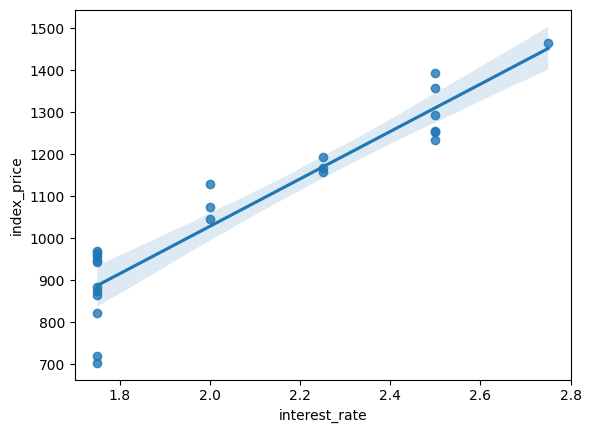

In [15]:
import seaborn as sns

sns.regplot(x=df_index['interest_rate'],y= df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

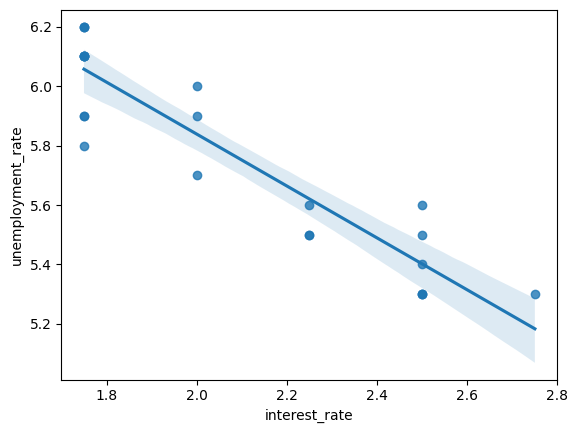

In [16]:
sns.regplot(x=df_index['interest_rate'],y= df_index['unemployment_rate'])

In [17]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler= StandardScaler()
X_train=  scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
X_test , X_train
##Y_test = scaler.fit_transform(Y_test)
##Y_train = scaler.fit_transform(Y_train)

(array([[ 0.36115756, -0.82078268],
        [-1.08347268,  1.33377186],
        [ 1.8057878 , -1.43636969],
        [-1.08347268,  1.02597835],
        [-0.36115756,  0.41039134],
        [ 0.36115756, -0.51298918]]),
 array([[-0.90115511,  0.37908503],
        [ 1.31077107, -1.48187786],
        [-0.90115511,  1.30956648],
        [ 1.31077107, -0.55139641],
        [ 1.31077107, -1.48187786],
        [-0.16384638,  0.68924552],
        [-0.90115511,  0.999406  ],
        [ 1.31077107, -1.48187786],
        [ 1.31077107, -1.17171738],
        [-0.90115511,  1.30956648],
        [-0.90115511,  0.999406  ],
        [-0.90115511,  0.37908503],
        [-0.90115511,  0.999406  ],
        [ 0.57346234, -0.8615569 ],
        [-0.16384638, -0.24123593],
        [-0.90115511,  0.06892455],
        [-0.90115511,  0.999406  ],
        [ 1.31077107, -0.8615569 ]]))

In [23]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [24]:
regression.fit(X_train , Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
from sklearn.model_selection import cross_val_score

validation_score = cross_val_score(regression , X_train , Y_train , scoring='neg_mean_squared_error' , cv=5)

In [28]:
validation_score

array([-0.04191565, -0.19623054, -0.17352894, -0.20643606, -0.01781615])

In [29]:
np.mean(validation_score)

np.float64(-0.1271854671472699)

In [30]:
##prediction

y_pred= regression.predict(X_test)

In [32]:
from sklearn.metrics import mean_absolute_error , mean_squared_error

mse = mean_squared_error(Y_test , y_pred)
mae = mean_absolute_error(Y_test , y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)


0.08706550137187996
0.27868311271502766
0.29506863840787956


In [33]:
##r2

from sklearn.metrics import r2_score
score = r2_score(Y_test, y_pred)
print (score)

0.91293449862812


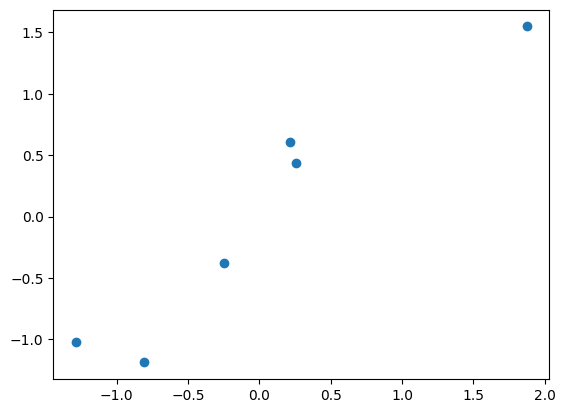

In [ ]:
##assumptions

plt.scatter(Y_test,y_pred)

##linear then good

In [35]:
residuals = Y_test=y_pred
print(residuals)

[[ 0.60403842]
 [-1.18955826]
 [ 1.54869373]
 [-1.01976998]
 [-0.37765405]
 [ 0.43425015]]


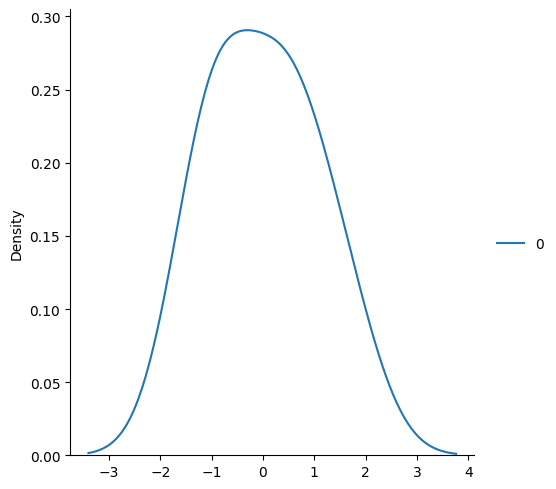

In [ ]:
sns.displot(residuals , kind= 'kde')

##gaustiosn curve then good

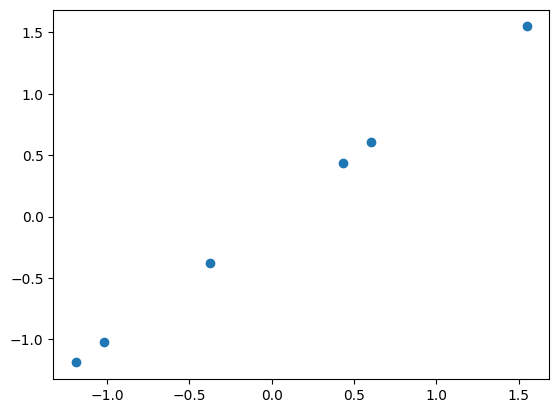

In [38]:
plt.scatter(y_pred , residuals)

In [41]:
print(regression.coef_)

[[ 0.41884681 -0.55163046]]


In [ ]:
from sklearn.pipeline import Pipeline